In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/AB Testing Data.csv")

In [ ]:
data.head()

,user_id,timestamp,group,landing_page,converted,age,gender,location,session_duration,pages_visited,device_type,purchase_amount
0,U1,2025-08-02 15:27:54.137058,control,old_page,0,37,Male,Pakistan,3.69,4,Mobile,0.0
1,U2,2024-04-22 10:22:51.712050,treatment,new_page,0,31,Female,UK,1.29,3,Desktop,0.0
2,U3,2024-08-14 21:35:11.135894,treatment,new_page,0,38,Male,US,3.72,5,Desktop,0.0
3,U4,2025-03-19 03:28:51.120807,treatment,new_page,0,28,Female,India,7.76,2,Mobile,0.0
4,U5,2024-12-22 13:13:17.973162,control,old_page,0,33,Male,Australia,6.78,6,Mobile,0.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   user_id           294478 non-null  object 
 1   timestamp         294478 non-null  object 
 2   group             294478 non-null  object 
 3   landing_page      294478 non-null  object 
 4   converted         294478 non-null  int64  
 5   age               294478 non-null  int64  
 6   gender            294478 non-null  object 
 7   location          294478 non-null  object 
 8   session_duration  294478 non-null  float64
 9   pages_visited     294478 non-null  int64  
 10  device_type       294478 non-null  object 
 11  purchase_amount   294478 non-null  float64
dtypes: float64(2), int64(3), object(7)
memory usage: 27.0+ MB


In [ ]:
data.shape

(294478, 12)

In [ ]:
data.describe()

,converted,age,session_duration,pages_visited,purchase_amount
count,294478.000000,294478.000000,294478.000000,294478.000000,294478.000000
mean,0.149172,31.902084,5.002136,4.019550,5.610490
std,0.356259,9.250043,1.980285,1.965182,15.438006
min,0.000000,18.000000,0.500000,1.000000,0.000000
25%,0.000000,25.000000,3.640000,3.000000,0.000000
50%,0.000000,32.000000,4.990000,4.000000,0.000000
75%,0.000000,38.000000,6.340000,5.000000,0.000000
max,1.000000,65.000000,13.730000,18.000000,269.280000


In [ ]:
data.describe(include="object")

,user_id,timestamp,group,landing_page,gender,location,device_type
count,294478,294478,294478,294478,294478,294478,294478
unique,294478,294478,2,2,3,7,3
top,U294478,2025-05-23 23:10:22.739522,treatment,new_page,Male,US,Desktop
freq,1,1,147552,147552,144708,88342,176692


In [ ]:
data.isnull().sum()

,0
user_id,0
timestamp,0
group,0
landing_page,0
converted,0
age,0
gender,0
location,0
session_duration,0
pages_visited,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data['user_id'].duplicated().sum()

np.int64(0)

In [ ]:
data['group'].value_counts()

,count
group,
treatment,147552
control,146926


In [ ]:
data['group'].value_counts(normalize=True)*100

,proportion
group,
treatment,50.10629
control,49.89371


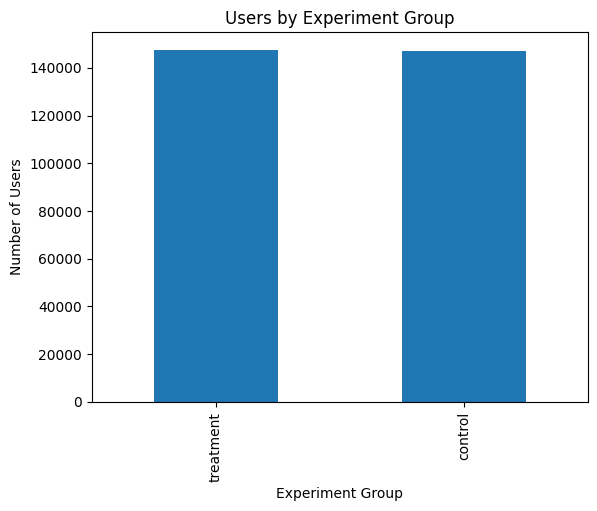

In [ ]:
data['group'].value_counts().plot(kind='bar')

plt.title("Users by Experiment Group")
plt.xlabel("Experiment Groups")
plt.ylabel("Number of Users")
plt.show()

In [ ]:
overall_conversion = data['converted'].mean() #Mean works here because the converted value is 1 for converted and 0 for not converted
print(f"Overall Conversion Rate : {overall_conversion:.2%}")

Overall Conversion Rate : 14.92%


In [ ]:
conversion_by_group = (
    data.groupby("group")['converted'].agg(["count","sum",'mean'])
)
conversion_by_group

,count,sum,mean
group,,,
control,146926,17444,0.118726
treatment,147552,26484,0.179489


In [ ]:
conversion_by_group.columns  = [
    'Users','Conversions','Conversion Rate'
]
conversion_by_group

,Users,Conversions,Conversion Rate
group,,,
control,146926,17444,11.872643
treatment,147552,26484,17.948926


Above are just the things we already done in the sql. Now, we will move to the stats for which we are using python.

In [ ]:
control = data[data['group'] == 'control']
treatment = data[data['group'] == 'treatment']

control_conversion = control['converted'].sum()
treatment_conversion = treatment['converted'].sum()

control_users = len(control)
treatment_users = len(treatment)

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

success = np.array([
    treatment_conversion,
    control_conversion
])

sample = np.array([
    treatment_users,
    control_users
])

z_stat, p_value = proportions_ztest(
    success,
    sample
)

print("Z-statistics : ", z_stat)
print("p_value : ", p_value)

Z-statistics :  46.277339891305736
p_value :  0.0


In [ ]:
from statsmodels.stats.proportion import confint_proportions_2indep

ci_low, ci_high = confint_proportions_2indep(
    treatment_conversion,
    treatment_users,
    control_conversion,
    control_users,
    method="wald"
)

print("95% CI:", ci_low, ci_high)

95% CI: 0.05819966678070663 0.06332599539255371


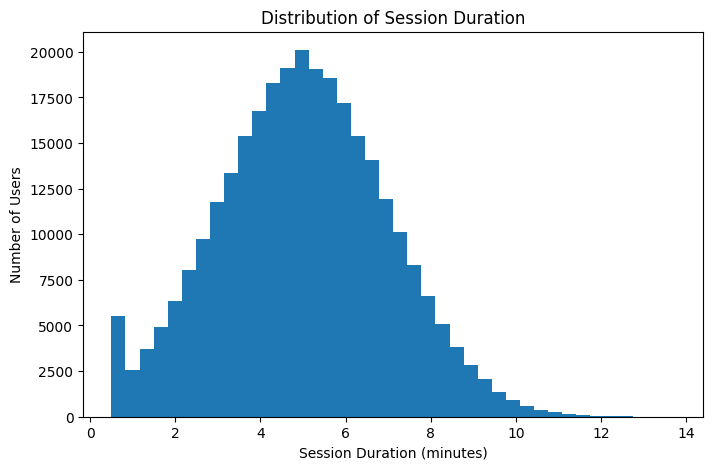

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    data["session_duration"],
    bins=40
)

plt.title("Distribution of Session Duration")
plt.xlabel("Session Duration (minutes)")
plt.ylabel("Number of Users")

plt.show()

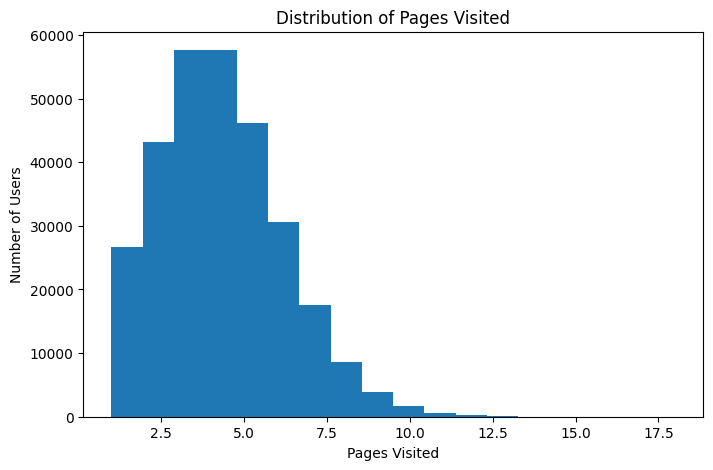

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    data["pages_visited"],
    bins=18
)

plt.title("Distribution of Pages Visited")
plt.xlabel("Pages Visited")
plt.ylabel("Number of Users")

plt.show()

In [ ]:
data.groupby("converted")[
    ["session_duration", "pages_visited", "purchase_amount"]
].mean()

,session_duration,pages_visited,purchase_amount
converted,,,
0,5.002408,4.018192,0.00000
1,5.000583,4.027295,37.61077


In [ ]:
device_conversion = (
    data.groupby(["device_type", "group"])["converted"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

device_conversion

,device_type,group,count,sum,mean
0,Desktop,control,88397,10563,0.119495
1,Desktop,treatment,88295,15966,0.180826
2,Mobile,control,51177,6010,0.117436
3,Mobile,treatment,51916,9196,0.177132
4,Tablet,control,7352,871,0.118471
5,Tablet,treatment,7341,1322,0.180084


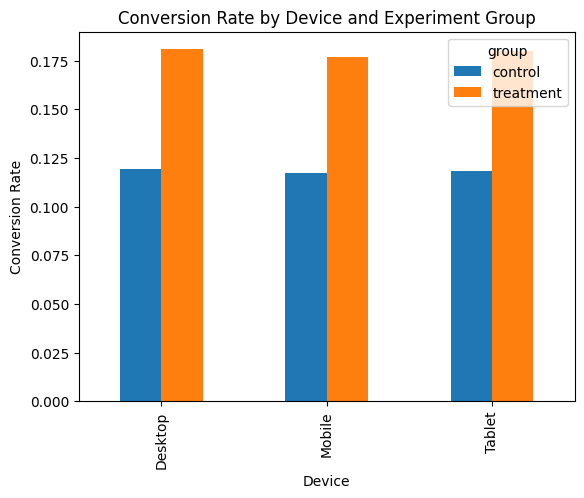

In [ ]:
pivot = device_conversion.pivot(
    index="device_type",
    columns="group",
    values="mean"
)

pivot.plot(kind="bar")

plt.title("Conversion Rate by Device and Experiment Group")
plt.xlabel("Device")
plt.ylabel("Conversion Rate")

plt.show()

In [ ]:
bins = [17, 24, 34, 44, 54, 65]

labels = [
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-65"
]

data["age_group"] = pd.cut(
    data["age"],
    bins=bins,
    labels=labels
)

In [ ]:
data['age_group'].value_counts()

,count
age_group,
25-34,110439
35-44,83995
18-24,71509
45-54,25343
55-65,3192


In [ ]:
age_conversion = (
    data.groupby(["age_group", "group"], observed=True)["converted"]
    .mean()
    .reset_index()
)

age_conversion

,age_group,group,converted
0,18-24,control,0.120131
1,18-24,treatment,0.180935
2,25-34,control,0.120602
3,25-34,treatment,0.179553
4,35-44,control,0.115344
5,35-44,treatment,0.179583
6,45-54,control,0.116879
7,45-54,treatment,0.175467
8,55-65,control,0.125778
9,55-65,treatment,0.174653


In [ ]:
data["timestamp"] = pd.to_datetime(data["timestamp"])

In [ ]:
data["date"] = data["timestamp"].dt.date
data['date']

,date
0,2025-08-02
1,2024-04-22
2,2024-08-14
3,2025-03-19
4,2024-12-22
...,...
294473,2024-07-30
294474,2025-02-06
294475,2024-08-06
294476,2024-03-30


In [ ]:
data["month"] = data["timestamp"].dt.to_period("M")
data['month']

,month
0,2025-08
1,2024-04
2,2024-08
3,2025-03
4,2024-12
...,...
294473,2024-07
294474,2025-02
294475,2024-08
294476,2024-03


In [ ]:
monthly_conversion = (
    data.groupby(["month", "group"])["converted"]
    .mean()
    .reset_index()
)

monthly_conversion

,month,group,converted
0,2023-08,control,0.091324
1,2023-08,treatment,0.169154
2,2023-09,control,0.110794
3,2023-09,treatment,0.176093
4,2023-10,control,0.124722
5,2023-10,treatment,0.179602
6,2023-11,control,0.116259
7,2023-11,treatment,0.181608
8,2023-12,control,0.121773
9,2023-12,treatment,0.181540


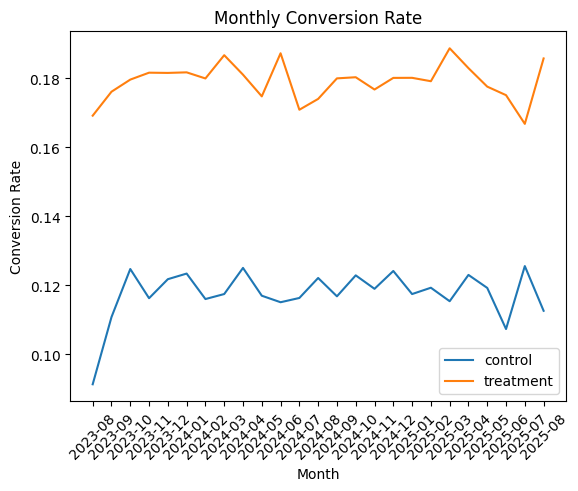

In [ ]:
for group in monthly_conversion["group"].unique():

    subset = monthly_conversion[
        monthly_conversion["group"] == group
    ]

    plt.plot(
        subset["month"].astype(str),
        subset["converted"],
        label=group
    )

plt.title("Monthly Conversion Rate")
plt.xlabel("Month")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45)
plt.legend()
plt.show()